# Event Study and Differences in Defferences

# Week 3

In [2]:
# libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

In [3]:
df1_w3 = pd.read_csv("homework_3.1.csv")
df1_w3.head()

,time,value1,value2,value3
0,0,1.764052,1.883151,-0.369182
1,1,0.420157,-1.327759,-0.219379
2,2,1.018738,-1.230485,1.139660
3,3,2.300893,1.029397,0.715264
4,4,1.947558,-1.093123,0.720132


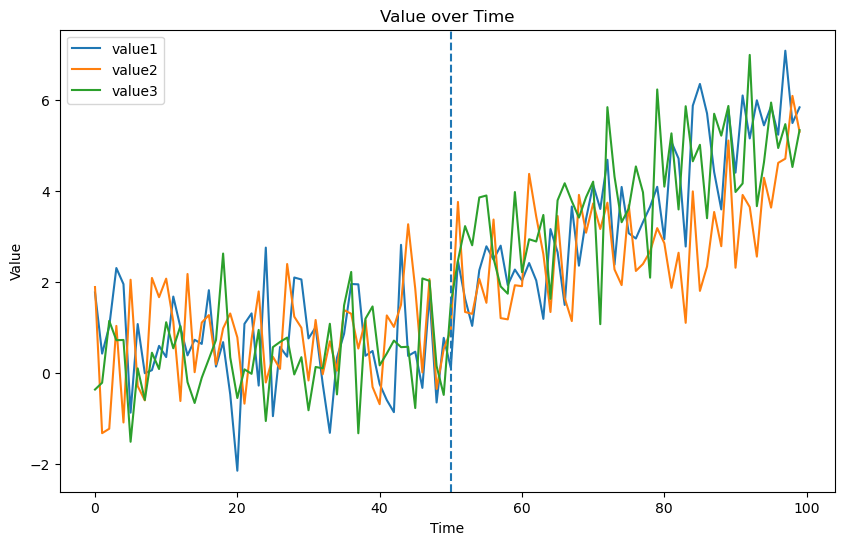

In [7]:
# Plotting
plt.figure(figsize=(10, 6))

plt.plot(df1_w3['time'], df1_w3['value1'], label='value1')
plt.plot(df1_w3['time'], df1_w3['value2'], label='value2')
plt.plot(df1_w3['time'], df1_w3['value3'], label='value3')

plt.axvline(x=50, linestyle='--')
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Value over Time")
plt.legend()
plt.show()

In [12]:
df1_w3["time_centered"] = df1_w3['time'] -50
df1_w3['post'] = (df1_w3['time'] >= 50).astype(int)
df1_w3.drop(columns=["time_centerate"], inplace=True)
df1_w3.head()


,time,value1,value2,value3,post,time_centered
0,0,1.764052,1.883151,-0.369182,0,-50
1,1,0.420157,-1.327759,-0.219379,0,-49
2,2,1.018738,-1.230485,1.139660,0,-48
3,3,2.300893,1.029397,0.715264,0,-47
4,4,1.947558,-1.093123,0.720132,0,-46


In [15]:
# Step 4 : first regression
# value1 = B0 + B1(Time) + B2(Post)

model1 = smf.ols(
    "value1 ~ time_centered + post",
    data = df1_w3
).fit()

print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                 value1   R-squared:                       0.651
Model:                            OLS   Adj. R-squared:                  0.644
Method:                 Least Squares   F-statistic:                     90.57
Date:                Fri, 25 Sep 2026   Prob (F-statistic):           6.48e-23
Time:                        11:49:57   Log-Likelihood:                -160.63
No. Observations:                 100   AIC:                             327.3
Df Residuals:                      97   BIC:                             335.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         1.7488      0.277      6.310

In [16]:

model2 = smf.ols(
    "value2 ~ time_centered + post",
    data = df1_w3
).fit()

print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                 value2   R-squared:                       0.540
Model:                            OLS   Adj. R-squared:                  0.530
Method:                 Least Squares   F-statistic:                     56.92
Date:                Fri, 25 Sep 2026   Prob (F-statistic):           4.44e-17
Time:                        11:59:34   Log-Likelihood:                -146.89
No. Observations:                 100   AIC:                             299.8
Df Residuals:                      97   BIC:                             307.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         1.4800      0.242      6.126

In [17]:

model3 = smf.ols(
    "value3 ~ time_centered + post",
    data = df1_w3
).fit()

print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:                 value3   R-squared:                       0.777
Model:                            OLS   Adj. R-squared:                  0.773
Method:                 Least Squares   F-statistic:                     169.3
Date:                Fri, 25 Sep 2026   Prob (F-statistic):           2.33e-32
Time:                        12:01:23   Log-Likelihood:                -141.75
No. Observations:                 100   AIC:                             289.5
Df Residuals:                      97   BIC:                             297.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         1.2903      0.229      5.623

In [19]:
# Step 5 : we are looking for slope after event so 
# Y = B0 + B1*Time + B2*Post + B3(Time * Post)
# B1*Time = Slope Before event
# B2*Post = Jump at Value
# B3(Time*Post ) = Slope changes after Event

model1_slope = smf.ols(
    "value1 ~ time_centered + post + time_centered:post",
    data= df1_w3
).fit()

print(model1_slope.summary())

                            OLS Regression Results                            
Dep. Variable:                 value1   R-squared:                       0.790
Model:                            OLS   Adj. R-squared:                  0.783
Method:                 Least Squares   F-statistic:                     120.2
Date:                Fri, 25 Sep 2026   Prob (F-statistic):           2.18e-32
Time:                        12:09:56   Log-Likelihood:                -135.33
No. Observations:                 100   AIC:                             278.7
Df Residuals:                      96   BIC:                             289.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.4059      0

In [20]:
model2_slope = smf.ols(
    "value2 ~ time_centered + post + time_centered:post",
    data = df1_w3
).fit()

print(model2_slope.summary())

                            OLS Regression Results                            
Dep. Variable:                 value2   R-squared:                       0.569
Model:                            OLS   Adj. R-squared:                  0.556
Method:                 Least Squares   F-statistic:                     42.33
Date:                Fri, 25 Sep 2026   Prob (F-statistic):           1.62e-17
Time:                        13:54:44   Log-Likelihood:                -143.57
No. Observations:                 100   AIC:                             295.1
Df Residuals:                      96   BIC:                             305.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              1.0093      0

In [22]:
model3_slope = smf.ols(
    "value3 ~ time_centered + post + time_centered:post",
    data= df1_w3
).fit()

print(model3_slope.summary())

                            OLS Regression Results                            
Dep. Variable:                 value3   R-squared:                       0.807
Model:                            OLS   Adj. R-squared:                  0.801
Method:                 Least Squares   F-statistic:                     133.9
Date:                Fri, 25 Sep 2026   Prob (F-statistic):           3.47e-34
Time:                        13:57:37   Log-Likelihood:                -134.55
No. Observations:                 100   AIC:                             277.1
Df Residuals:                      96   BIC:                             287.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.6439      0

## Event Discontinuity Analysis — Questions 1 & 2

The goal of this analysis was to examine what happened at the event point (`time = 50`). We looked for two different types of changes:

- **Level discontinuity:** a sudden jump in the value at the event.
- **Slope discontinuity:** a change in the rate or direction of the trend after the event.

### Step 1: Prepare the Data

I centered time around the event so that `time = 50` became `time_centered = 0`.

I also created a `post` variable:
- `post = 0` before the event
- `post = 1` at and after the event

This makes it easier to estimate what changes exactly at the event.

### Question 1: Which variable has the strongest discontinuity in value?

First, I used:

`value ~ time_centered + post`

Here, the coefficient of **`post`** represents the jump in value at the event.

Results:

| Variable | Post Coefficient | P-value |
|---|---:|---:|
| value1 | 0.8508 | 0.086 |
| value2 | 0.6827 | 0.113 |
| value3 | 1.7673 | < 0.001 |

**Answer: value3**

`value3` has the largest jump at the event (about 1.77 units), and the effect is statistically significant.

### Question 2: Which variable has the strongest discontinuity in the derivative?

Derivative here means the **slope**, or how quickly the value changes over time.

To allow the slope to change after the event, I added an interaction term:

`value ~ time_centered + post + time_centered:post`

The coefficient of **`time_centered:post`** tells us how much the slope changes after the event.

| Variable | Change in Slope | P-value |
|---|---:|---:|
| value1 | 0.1053 | < 0.001 |
| value2 | 0.0369 | 0.012 |
| value3 | 0.0507 | < 0.001 |

**Answer: value1**

`value1` has the largest change in slope, so it shows the strongest discontinuity in the derivative.

### Key Takeaway

- **`post` → change in level (jump)**
- **`time_centered:post` → change in slope (derivative)**

So, a level discontinuity asks **"Did the value suddenly jump?"**, while a derivative discontinuity asks **"Did the trend suddenly change?"**

# Differences in Differences

In [23]:
# Step 1 : read two new datasets 
df_group1_w3 = pd.read_csv("homework_3.2.a.csv")
df_group2_w3 = pd.read_csv("homework_3.2.b.csv")

print("Group 1:")
display(df_group1_w3.head())

print("Group 2:")
display(df_group2_w3.head())

Group 1:


,group1,time1,outcome1
0,0,0,0.882026
1,0,1,1.600079
2,0,0,0.489369
3,0,1,2.520447
4,0,0,0.933779


Group 2:


,group2,time2,outcome2
0,0,0,0.667155
1,0,1,2.470969
2,0,0,-0.506778
3,0,1,1.525657
4,0,0,0.273664


group = 0 -> Control group | 

group = 1 -> treatment group | 

time = 0 -> before treatment | 

time = 1 -> after treatment | 

outcome = result

DID Regression :

Outcome = B0 + B1*Group + B2 * Time + B3(Group * Time)

B3 = Treatment Effect

In [24]:
# Step 2 : Regression for group 1

did_group1 = smf.ols(
    "outcome1 ~ group1 + time1 + group1:time1",
    data = df_group1_w3
).fit()

print(did_group1.summary())

                            OLS Regression Results                            
Dep. Variable:               outcome1   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                     2964.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        14:17:36   Log-Likelihood:                -712.28
No. Observations:                1000   AIC:                             1433.
Df Residuals:                     996   BIC:                             1452.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -0.0258      0.031     -0.829   

In [25]:

did_group2 = smf.ols(
    "outcome2 ~ group2 + time2 + group2:time2",
    data = df_group2_w3
).fit()

print(did_group2.summary())

                            OLS Regression Results                            
Dep. Variable:               outcome2   R-squared:                       0.663
Model:                            OLS   Adj. R-squared:                  0.662
Method:                 Least Squares   F-statistic:                     653.6
Date:                Fri, 25 Sep 2026   Prob (F-statistic):          9.62e-235
Time:                        14:20:43   Log-Likelihood:                -1567.5
No. Observations:                1000   AIC:                             3143.
Df Residuals:                     996   BIC:                             3163.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.1021      0.073      1.392   

In [26]:
df_group2_w3.groupby(["group2","time2"])["outcome2"].mean()

group2  time2
0       0        0.102107
        1        1.367621
1       0        1.949826
        1        4.565198
Name: outcome2, dtype: float64

In [27]:
(4.565198 - 1.949826)-(1.367621 - 0.102107)

1.3498579999999998

## Differences-in-Differences (DiD) – Summary

In this section, I used Difference-in-Differences (DiD) to estimate the treatment effect for two datasets.

The main idea of DiD is to compare how the treatment group changes over time with how the control group changes over the same period:

**DiD = (Treatment After − Treatment Before) − (Control After − Control Before)**

This approach assumes **parallel trends**, meaning that without the treatment, the treatment and control groups would have followed similar trends over time.

### Method

For each dataset, I ran the following regression:

`outcome ~ group + time + group:time`

The interaction term `group:time` is the key coefficient because it represents the estimated **treatment effect (DiD effect)**.

### Results

- **Group 1:** Treatment effect ≈ 0.686, SE ≈ 0.063, t ≈ 10.97
- **Group 2:** Treatment effect ≈ 1.350, SE ≈ 0.147, t ≈ 9.18

### Questions

**Q3: Which dataset has the largest treatment effect?**  
**Answer: Group 2.**  
Its estimated treatment effect (≈ 1.35) is larger than Group 1 (≈ 0.69).

**Q4: Which dataset has the most statistically significant nonzero treatment effect?**  
**Answer: Group 1.**  
Both effects are statistically significant, but Group 1 has the larger t-statistic because its effect is estimated more precisely relative to its standard error.

**Q5: Which option is closest to the treatment effect for Group 2?**  
**Answer: 1.248.**  
Our estimated DiD effect is about 1.35, and 1.248 is the closest option provided.

### Key Takeaway

A **larger treatment effect does not necessarily mean stronger statistical significance**.  
Effect size tells us **how large the estimated impact is**, while the standard error and t-statistic tell us **how precisely that effect is estimated**.